In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("/retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 9


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [ ]:
# Descriptive Statistics

numeric_columns = df.select_dtypes(include=np.number).columns

statistics = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0],
    "Standard Deviation": df[numeric_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [ ]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].dtype)

datetime64[ns]


In [ ]:
# Create time-based columns

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Month_Name,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,November,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,February,1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,January,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,May,2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,May,2


## Initial Dataset Findings

The retail sales dataset contains 1,000 transaction records and 9 columns.
There are no missing values or duplicate records in the dataset.

The dataset contains customer demographic information such as gender and
age, along with transaction details including product category, quantity,
price per unit, and total amount.

The Date column was converted into datetime format to support monthly and
quarterly sales trend analysis.


In [ ]:
# Monthly Sales Analysis

monthly_sales = df.groupby(
    ["Year", "Month"]
)["Total Amount"].sum().reset_index()

monthly_sales["Month_Year"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

monthly_sales

,Year,Month,Total Amount,Month_Year
0,2023,1,35450,2023-01
1,2023,2,44060,2023-02
2,2023,3,28990,2023-03
3,2023,4,33870,2023-04
4,2023,5,53150,2023-05
5,2023,6,36715,2023-06
6,2023,7,35465,2023-07
7,2023,8,36960,2023-08
8,2023,9,23620,2023-09
9,2023,10,46580,2023-10


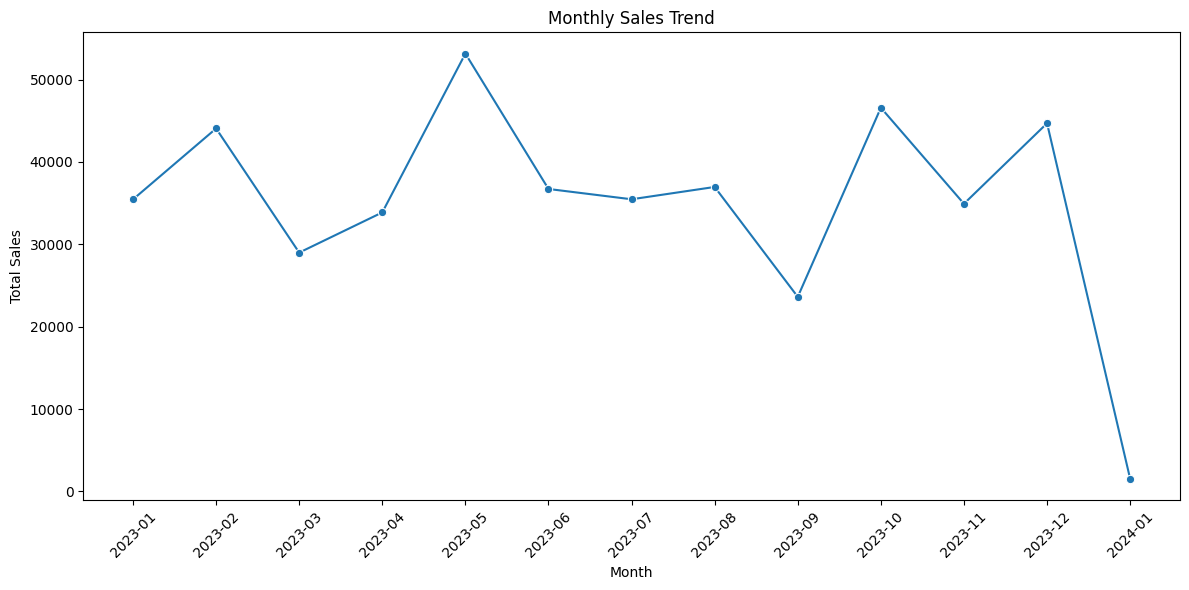

In [ ]:
# Monthly Sales Trend

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month_Year",
    y="Total Amount",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

Monthly sales fluctuate throughout the period. Sales reached the highest
level in May 2023 with total sales of 53,150. October and December 2023
also recorded relatively high sales.

September 2023 recorded the lowest sales among the complete months of 2023,
with total sales of 23,620. January 2024 shows a much lower value, but this
month appears to contain only partial data, so it should not be directly
compared with the complete months of 2023.


In [ ]:
# Quarterly Sales Analysis

quarterly_sales = df.groupby(
    ["Year", "Quarter"]
)["Total Amount"].sum().reset_index()

quarterly_sales["Year_Quarter"] = (
    quarterly_sales["Year"].astype(str)
    + " Q"
    + quarterly_sales["Quarter"].astype(str)
)

quarterly_sales

,Year,Quarter,Total Amount,Year_Quarter
0,2023,1,108500,2023 Q1
1,2023,2,123735,2023 Q2
2,2023,3,96045,2023 Q3
3,2023,4,126190,2023 Q4
4,2024,1,1530,2024 Q1


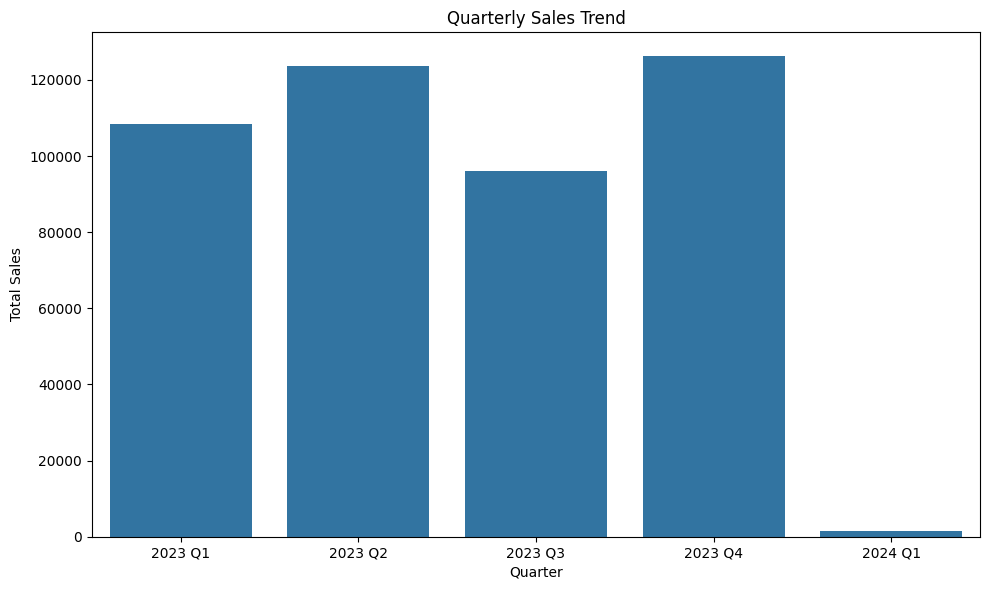

In [ ]:
# Quarterly Sales Trend

plt.figure(figsize=(10, 6))

sns.barplot(
    data=quarterly_sales,
    x="Year_Quarter",
    y="Total Amount"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Quarterly Sales Observation

Quarterly sales varied during 2023. The highest quarterly sales were recorded
in Q4 2023 with total sales of 126,190, followed by Q2 2023 with 123,735.

Q3 2023 recorded the lowest sales among the complete quarters of 2023,
with total sales of 96,045.

The value for Q1 2024 is only 1,530 and appears to represent partial data,
so it should not be directly compared with the complete quarters of 2023.

In [ ]:
# Sales by Product Category

category_sales = df.groupby(
    "Product Category"
)["Total Amount"].sum().sort_values(ascending=False)

category_sales

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


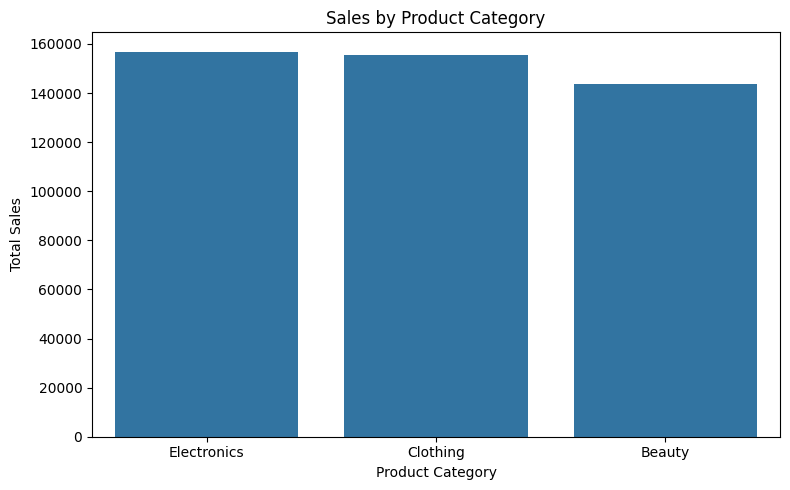

In [ ]:
# Product Category Sales

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Product Category Observation

Electronics generated the highest total sales at 156,905, followed closely
by Clothing at 155,580. Beauty generated 143,515 in total sales.

The sales difference between Electronics and Clothing is relatively small,
while Beauty recorded a lower total compared with the other two categories.

In [ ]:
# Customer Gender Distribution

gender_counts = df["Gender"].value_counts()

gender_counts

,count
Gender,
Female,510
Male,490


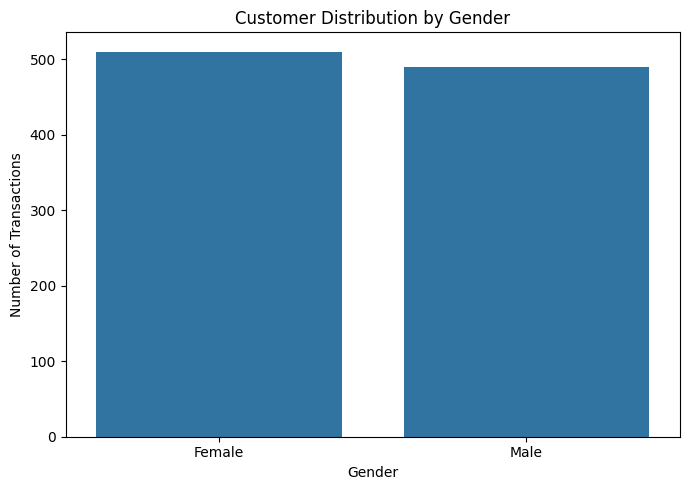

In [ ]:
# Gender Distribution Chart

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

### Gender Distribution Observation

The dataset contains 510 female customer transactions and 490 male customer
transactions. The distribution is relatively balanced, with female
transactions slightly higher than male transactions.

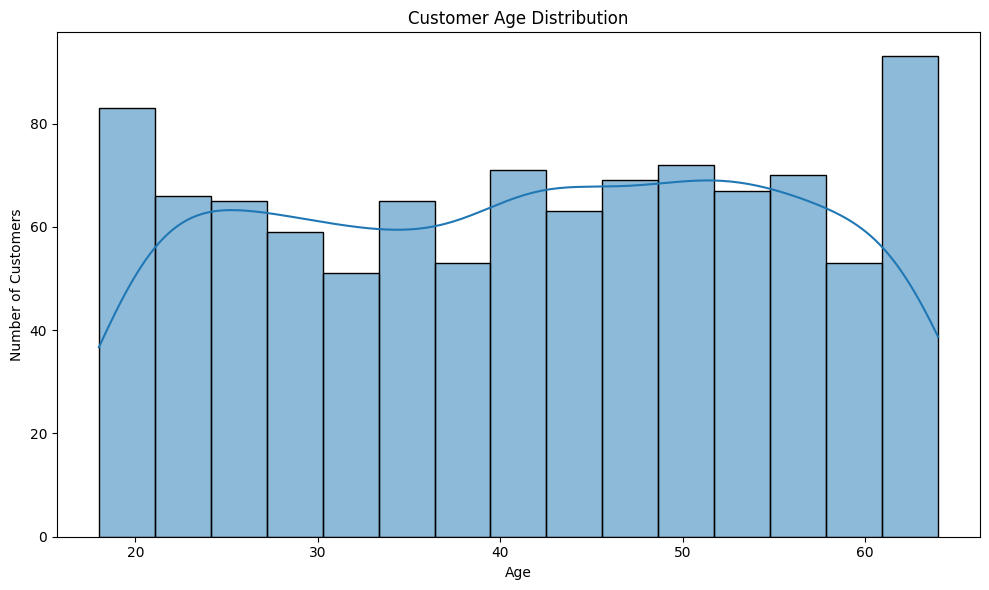

In [ ]:
# Customer Age Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [ ]:
# Age Group Analysis

age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

age_group_counts = df["Age Group"].value_counts().sort_index()

age_group_counts

,count
Age Group,
18-24,149
25-34,203
35-44,207
45-54,225
55-64,216


### Age Distribution Observation

The customer ages range from 18 to 64 years. The 45-54 age group has the
highest number of customers with 225 transactions, followed by the 55-64
age group with 216 transactions. The 18-24 age group has the lowest
representation with 149 transactions.

In [ ]:
# Sales by Gender

gender_sales = df.groupby("Gender")["Total Amount"].sum().sort_values(ascending=False)

print("Total Sales by Gender:")
print(gender_sales)

Total Sales by Gender:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


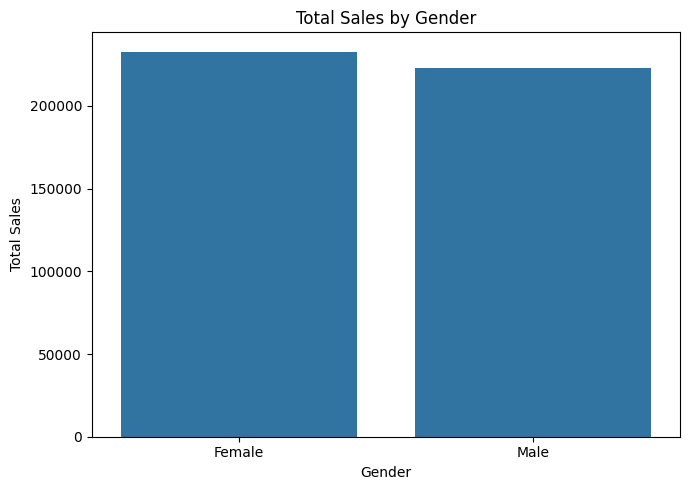

In [ ]:
# Sales by Gender Chart

plt.figure(figsize=(7, 5))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [ ]:
# Sales by Age Group

age_group_sales = df.groupby("Age Group")["Total Amount"].sum()

age_group_sales

/tmp/ipykernel_6755/1878695883.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_sales = df.groupby("Age Group")["Total Amount"].sum()


,Total Amount
Age Group,
18-24,74650
25-34,97090
35-44,96835
45-54,97235
55-64,90190


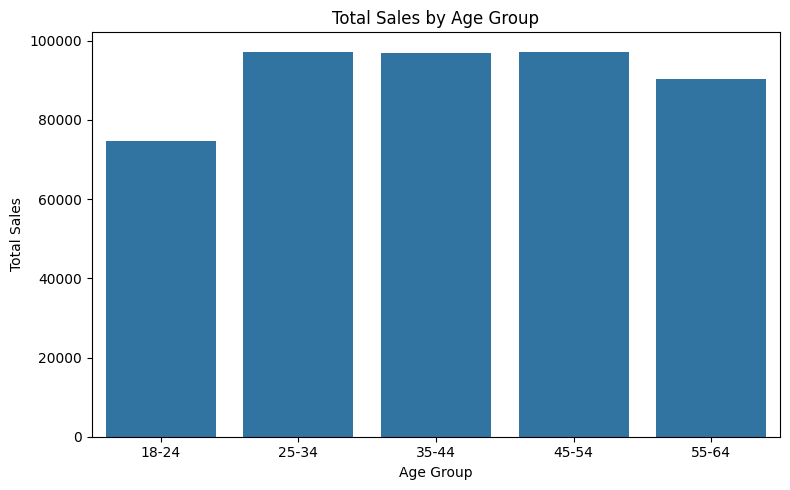

In [ ]:
# Sales by Age Group Chart

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_group_sales.index,
    y=age_group_sales.values
)

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Age Group Sales Observation

The 45-54 age group generated the highest total sales of ₹97,235.
The 35-44 age group generated ₹96,835, while the 25-34 age group
generated ₹97,090. The 18-24 age group had the lowest total sales
of ₹74,650.

In [ ]:
# Sales by Product Category and Gender

category_gender_sales = df.groupby(
    ["Product Category", "Gender"]
)["Total Amount"].sum().unstack()

category_gender_sales

Gender,Female,Male
Product Category,,
Beauty,74830,68685
Clothing,81275,74305
Electronics,76735,80170


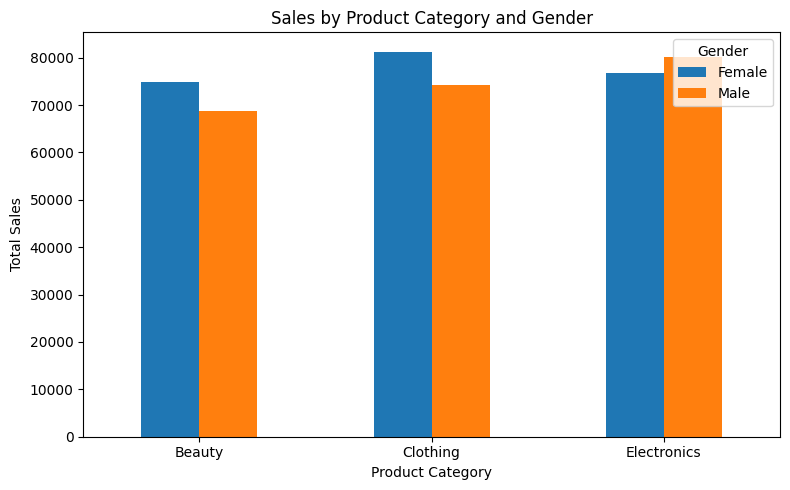

In [ ]:
# Product Category and Gender Sales Comparison

category_gender_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by Product Category and Gender")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Total Quantity Sold by Product Category

category_quantity = df.groupby(
    "Product Category"
)["Quantity"].sum().sort_values(ascending=False)

category_quantity

,Quantity
Product Category,
Clothing,894
Electronics,849
Beauty,771


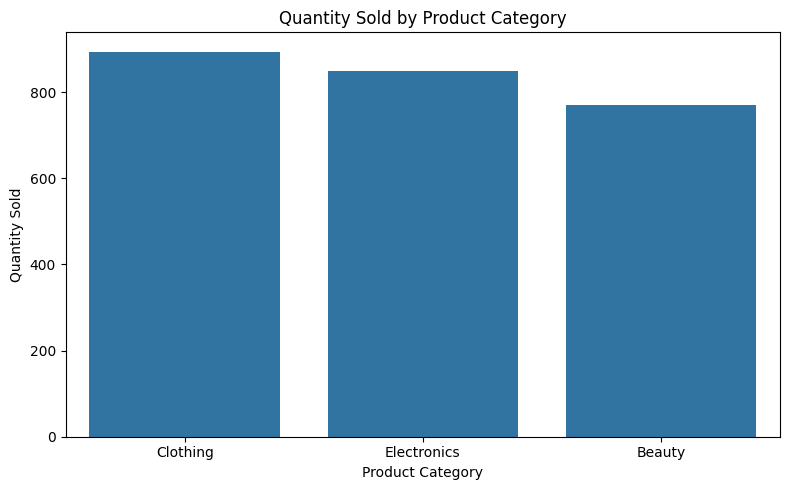

In [ ]:
# Quantity Sold by Product Category

plt.figure(figsize=(8, 5))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")

plt.tight_layout()
plt.show()

In [ ]:
# Average Transaction Amount

average_transaction = df["Total Amount"].mean()

print("Average Transaction Amount:", average_transaction)

Average Transaction Amount: 456.0


In [ ]:
# Average Transaction Amount by Product Category

avg_category_sales = df.groupby(
    "Product Category"
)["Total Amount"].mean().sort_values(ascending=False)

avg_category_sales

,Total Amount
Product Category,
Beauty,467.475570
Electronics,458.786550
Clothing,443.247863


In [ ]:
# Average Transaction Amount by Gender

avg_gender_sales = df.groupby(
    "Gender"
)["Total Amount"].mean().sort_values(ascending=False)

avg_gender_sales

,Total Amount
Gender,
Female,456.549020
Male,455.428571


In [ ]:
# Average Transaction Amount by Age Group

avg_age_group_sales = df.groupby(
    "Age Group"
)["Total Amount"].mean().sort_values(ascending=False)

avg_age_group_sales

/tmp/ipykernel_6755/827030083.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_age_group_sales = df.groupby(


,Total Amount
Age Group,
18-24,501.006711
25-34,478.275862
35-44,467.801932
45-54,432.155556
55-64,417.546296


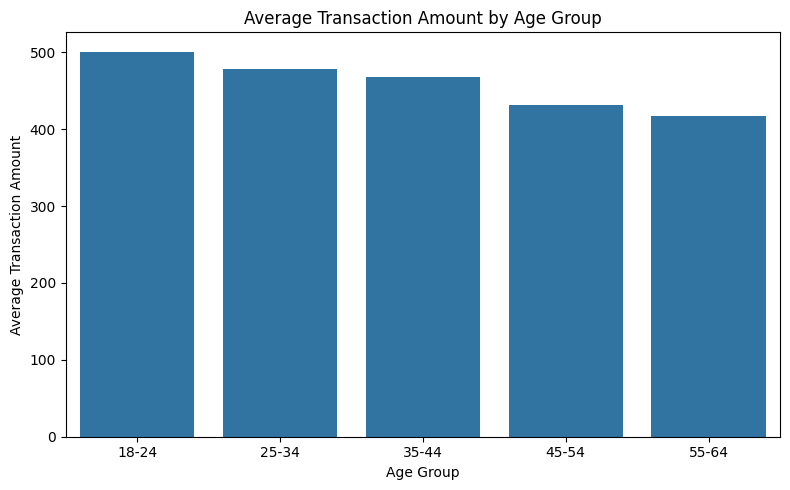

In [ ]:
# Average Transaction Amount by Age Group

plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_age_group_sales.index,
    y=avg_age_group_sales.values
)

plt.title("Average Transaction Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")

plt.tight_layout()
plt.show()

In [ ]:
# Sales by Age Group and Gender

age_gender_sales = df.groupby(
    ["Age Group", "Gender"]
)["Total Amount"].sum().unstack()

age_gender_sales

/tmp/ipykernel_6755/213208404.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_sales = df.groupby(


Gender,Female,Male
Age Group,,
18-24,35920,38730
25-34,51850,45240
35-44,52965,43870
45-54,46825,50410
55-64,45280,44910


<Figure size 900x500 with 0 Axes>

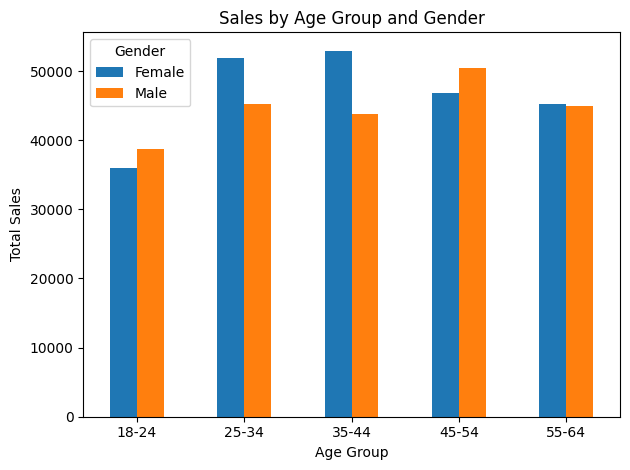

In [ ]:
# Sales by Age Group and Gender

plt.figure(figsize=(9, 5))

age_gender_sales.plot(kind="bar")

plt.title("Sales by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

In [ ]:
# Sales by Age Group and Product Category

age_category_sales = df.groupby(
    ["Age Group", "Product Category"]
)["Total Amount"].sum().unstack()

age_category_sales

/tmp/ipykernel_6755/476032915.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_category_sales = df.groupby(


Product Category,Beauty,Clothing,Electronics
Age Group,,,
18-24,28905,22160,23585
25-34,28540,41640,26910
35-44,29450,30925,36460
45-54,35950,29545,31740
55-64,20670,31310,38210


<Figure size 1000x600 with 0 Axes>

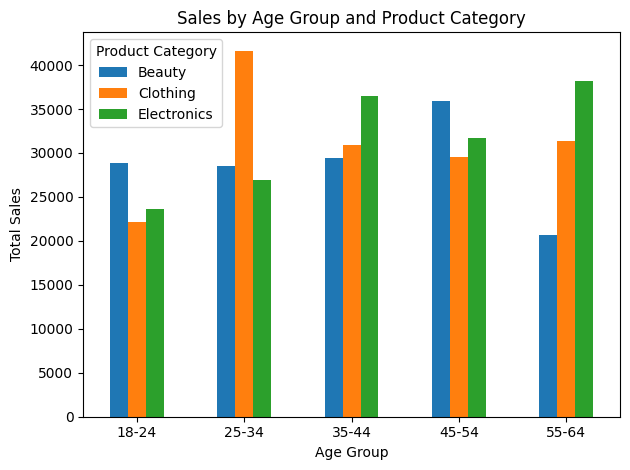

In [ ]:
# Sales by Age Group and Product Category

plt.figure(figsize=(10, 6))

age_category_sales.plot(kind="bar")

plt.title("Sales by Age Group and Product Category")
plt.xlabel("Age Group")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.legend(title="Product Category")

plt.tight_layout()
plt.show()

In [ ]:
# Highest and Lowest Sales Month

highest_month = monthly_sales.loc[
    monthly_sales["Total Amount"].idxmax()
]

lowest_month = monthly_sales.loc[
    monthly_sales["Total Amount"].idxmin()
]

print("Highest Sales Month:")
print(highest_month)

print("\nLowest Sales Month:")
print(lowest_month)


Highest Sales Month:
Year               2023
Month                 5
Total Amount      53150
Month_Year      2023-05
Name: 4, dtype: object

Lowest Sales Month:
Year               2024
Month                 1
Total Amount       1530
Month_Year      2024-01
Name: 12, dtype: object


In [ ]:
# Year-wise Total Sales

yearly_sales = df.groupby("Year")["Total Amount"].sum().sort_values(ascending=False)

yearly_sales

,Total Amount
Year,
2023,454470
2024,1530


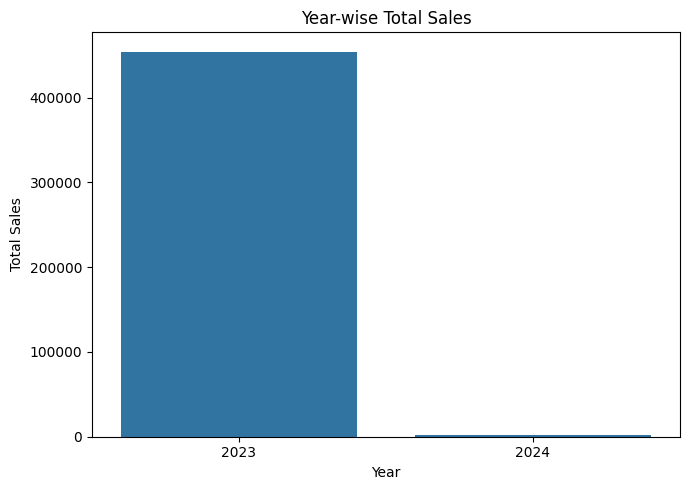

In [ ]:
# Year-wise Total Sales

plt.figure(figsize=(7, 5))

sns.barplot(
    x=yearly_sales.index.astype(str),
    y=yearly_sales.values
)

plt.title("Year-wise Total Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [ ]:
# Monthly Sales Analysis

monthly_sales = df.groupby(
    ["Year", "Month"]
)["Total Amount"].sum().reset_index()

monthly_sales["Month_Year"] = (
    monthly_sales["Year"].astype(str)
    + "-"
    + monthly_sales["Month"].astype(str).str.zfill(2)
)

monthly_sales

,Year,Month,Total Amount,Month_Year
0,2023,1,35450,2023-01
1,2023,2,44060,2023-02
2,2023,3,28990,2023-03
3,2023,4,33870,2023-04
4,2023,5,53150,2023-05
5,2023,6,36715,2023-06
6,2023,7,35465,2023-07
7,2023,8,36960,2023-08
8,2023,9,23620,2023-09
9,2023,10,46580,2023-10


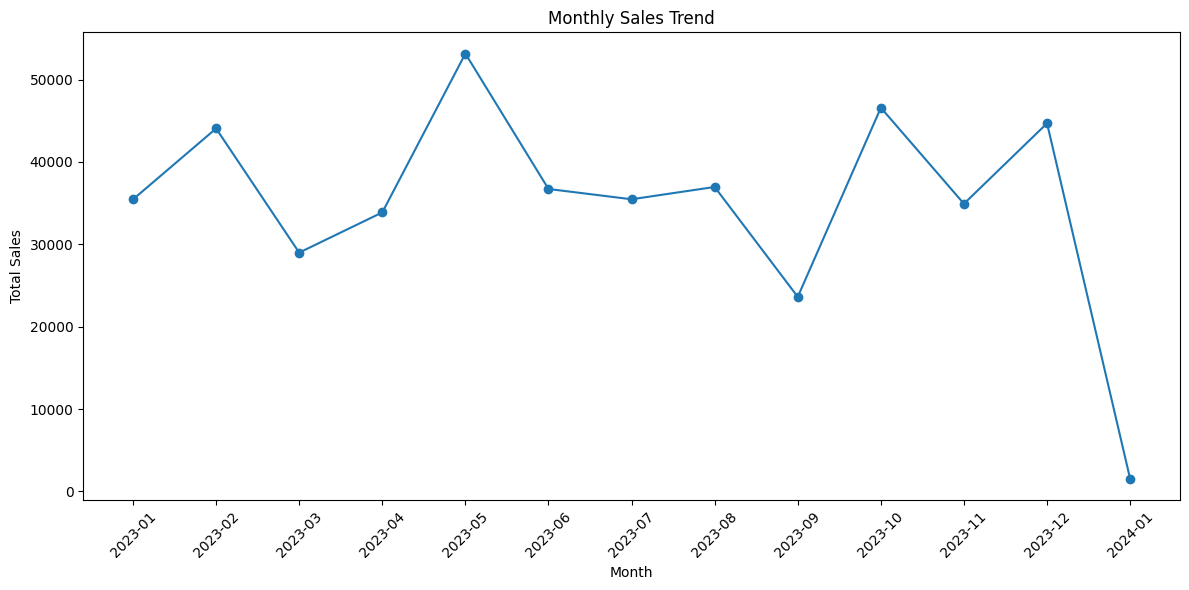

In [ ]:
# Monthly Sales Analysis Chart

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["Month_Year"],
    monthly_sales["Total Amount"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Quarterly Sales Analysis

df["Quarter"] = "Q" + df["Month"].astype(str).map(
    lambda x: str((int(x) - 1) // 3 + 1)
)

quarterly_sales = df.groupby(
    ["Year", "Quarter"]
)["Total Amount"].sum()

quarterly_sales

Year  Quarter
2023  Q1         108500
      Q2         123735
      Q3          96045
      Q4         126190
2024  Q1           1530
Name: Total Amount, dtype: int64

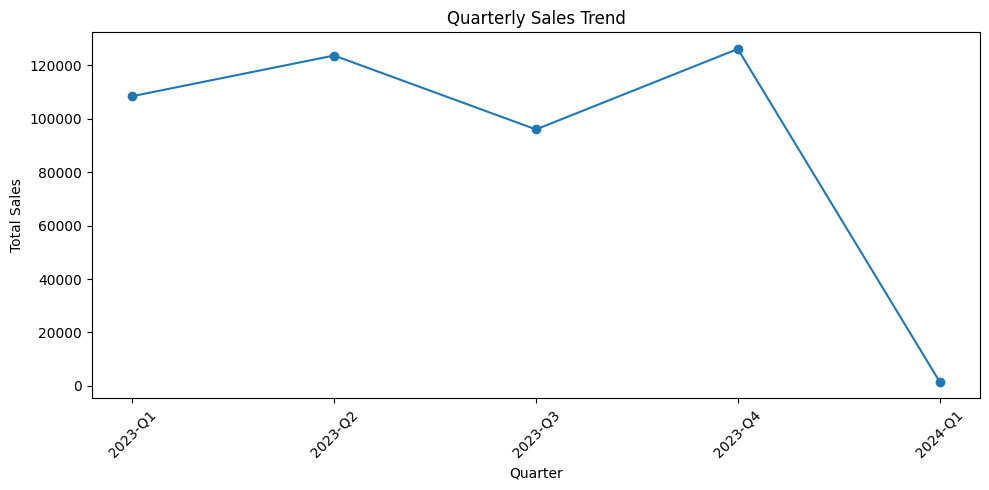

In [ ]:
# Quarterly Sales Trend

quarterly_sales_plot = quarterly_sales.reset_index()

quarterly_sales_plot["Period"] = (
    quarterly_sales_plot["Year"].astype(str)
    + "-"
    + quarterly_sales_plot["Quarter"]
)

plt.figure(figsize=(10, 5))

plt.plot(
    quarterly_sales_plot["Period"],
    quarterly_sales_plot["Total Amount"],
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Check product-related columns
for col in df.columns:
    print(col)

Transaction ID
Date
Customer ID
Gender
Age
Product Category
Quantity
Price per Unit
Total Amount
Year
Month
Month_Name
Quarter
Age Group


In [ ]:
# Check whether a Product Name column exists

product_columns = [
    col for col in df.columns
    if "product" in col.lower()
]

print("Product-related columns:")
for col in product_columns:
    print(col)

Product-related columns:
Product Category


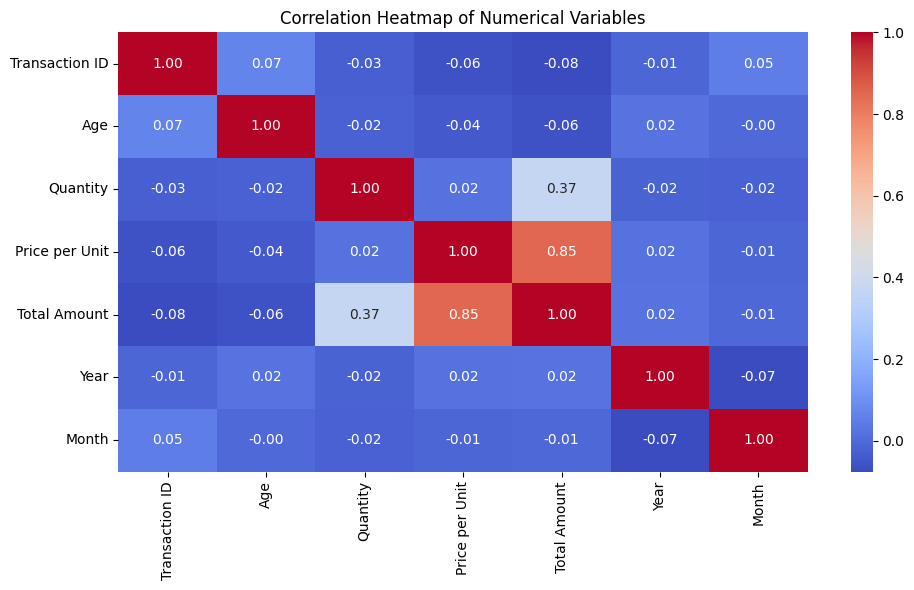

In [ ]:
# Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numeric_df = df.select_dtypes(include="number")

# Create correlation matrix
correlation = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows that Price per Unit has a strong positive relationship with Total Amount (0.85). This means transactions with higher-priced items generally contribute to higher total sales.

Quantity has a moderate positive relationship with Total Amount (0.37), indicating that selling more units also contributes to higher sales, but its relationship is weaker than Price per Unit.

The other numerical variables show very weak correlations with Total Amount. Overall, Price per Unit appears to be the most strongly related numerical factor to Total Amount in this dataset.

/tmp/ipykernel_6755/3356854249.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_gender_avg = df.groupby(


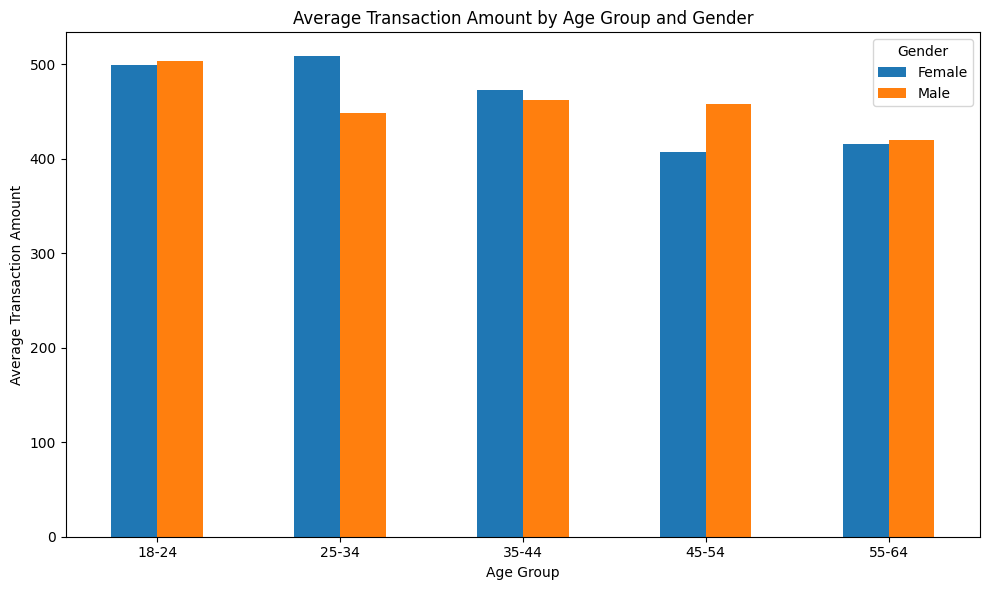

In [ ]:
# Additional Visualization: Average Sales by Age Group and Gender

age_gender_avg = df.groupby(
    ["Age Group", "Gender"]
)["Total Amount"].mean().unstack()

age_gender_avg.plot(kind="bar", figsize=(10, 6))

plt.title("Average Transaction Amount by Age Group and Gender")
plt.xlabel("Age Group")
plt.ylabel("Average Transaction Amount")
plt.xticks(rotation=0)
plt.legend(title="Gender")

plt.tight_layout()
plt.show()

### Observation

The average transaction amount varies across both age groups and gender.
Female customers have higher average transaction amounts in the 25-34 and
35-44 age groups, while male customers have higher averages in the 18-24
and 45-54 age groups. The 55-64 age group shows almost similar spending
between males and females.

This indicates that customer spending behaviour differs by both age and
gender, which can help businesses design more targeted marketing strategies.

# Conclusion

The exploratory analysis of the retail sales dataset reveals useful patterns in customer spending and sales performance.

### Key Business Recommendations

1. **Focus on high-value transactions:**  
   Price per Unit has a strong positive relationship with Total Amount (0.85). The business can focus on promoting suitable higher-value products and bundles to increase revenue.

2. **Use age and gender-based marketing:**  
   Average transaction behaviour differs across age groups and genders. Marketing campaigns can be tailored to specific customer segments based on their spending patterns.

3. **Monitor monthly and quarterly sales trends:**  
   Sales vary considerably across months and quarters. The business should monitor low-performing periods and plan suitable promotions or campaigns to improve sales during those periods.

Overall, the analysis provides insights into customer behaviour, product-category performance, and sales trends that can support data-driven business decisions.
